# Adult Income kNN Classifier

This notebook builds and evaluates a **k-Nearest Neighbors (kNN)** classifier to predict whether a person's income is `>50K` or `<=50K`.

## Experiment Goals

- Build a clear and reproducible kNN baseline.
- Separate the labeled data into development data, a final holdout split, and the competition test set.
- Use **5-fold cross-validation** to choose the best `k` and related hyperparameters.
- Measure final performance on a **holdout** split that is not used for model selection.
- Save the selected hyperparameters, final metrics, and submission file.

## How To Read This Notebook

The workflow follows a standard supervised machine learning process:

1. **Labeled training data**: examples with input features `X` and known target labels `income`.
2. **Holdout split**: part of the training data is reserved for final evaluation.
3. **Cross-validation**: the remaining development data is split into 5 folds to compare hyperparameters.
4. **Model selection**: the model with the highest mean cross-validation accuracy is selected.
5. **Final evaluation**: accuracy, error rate, precision, recall/sensitivity, specificity, F1-score, ROC AUC, and the confusion matrix are computed on the holdout split.
6. **Final training**: after model selection, the selected pipeline is fit again on the full labeled training set and used to generate the submission.

## Note About Epochs

Some models, such as neural networks, train over multiple **epochs**. kNN does not work that way. During fitting, kNN mainly stores the transformed training examples. During prediction, it compares each new sample with the nearest stored samples and predicts from their votes. Therefore, the number of epochs is **not applicable** for this model.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)


In [2]:
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data" / "prepared" / "adult_income").exists():
            return candidate
    raise FileNotFoundError("Could not find data/prepared/adult_income from the current working directory.")


PROJECT_ROOT = resolve_project_root()
PREPARED_DIR = PROJECT_ROOT / "data" / "prepared" / "adult_income"
TRAIN_PREPARED_PATH = PREPARED_DIR / "train_prepared.csv"
TEST_PREPARED_PATH = PREPARED_DIR / "test_prepared.csv"
SAMPLE_SUBMISSION_PATH = PREPARED_DIR / "sample_submission.csv"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

train_prepared = pd.read_csv(TRAIN_PREPARED_PATH)
test_prepared = pd.read_csv(TEST_PREPARED_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

ID_COL = "Id"
TARGET_COL = "income"
NEGATIVE_LABEL = "<=50K"
POSITIVE_LABEL = ">50K"

assert ID_COL in train_prepared.columns, "train_prepared.csv must contain Id."
assert TARGET_COL in train_prepared.columns, "train_prepared.csv must contain income."
assert ID_COL in test_prepared.columns, "test_prepared.csv must contain Id."
assert TARGET_COL not in test_prepared.columns, "test_prepared.csv must not contain income."
assert sample_submission.columns.tolist() == [ID_COL, TARGET_COL], "sample_submission.csv must have columns Id and income."
assert len(sample_submission) == len(test_prepared), "sample_submission.csv row count must match test_prepared.csv."
assert set(train_prepared[TARGET_COL].unique()) == {NEGATIVE_LABEL, POSITIVE_LABEL}, "Unexpected training labels found in income."

print(f"Project root: {PROJECT_ROOT}")
print(f"Train prepared shape: {train_prepared.shape}")
print(f"Test prepared shape: {test_prepared.shape}")
print(f"Sample submission shape: {sample_submission.shape}")


Project root: /home/matheuscm/classifier-adults-dataset
Train prepared shape: (32536, 29)
Test prepared shape: (16280, 28)
Sample submission shape: (16280, 2)


## Features and Target Variable

The target variable is `income`, converted into a binary classification target:

- `0`: `<=50K`
- `1`: `>50K`

kNN is very sensitive to scale and distance. For that reason, this notebook uses a compact feature set instead of every prepared feature from notebook 02.

The selected numeric features are median-imputed and robust-scaled. The selected categorical features are missing-value-imputed and one-hot encoded. This gives kNN a consistent numeric feature space for distance calculations.

In kNN, the data is not represented as a simple 2D chart where `X = features` and `Y = income`. Each row becomes a point in a multidimensional space. Numeric features become numeric dimensions, and categorical features become binary dimensions after one-hot encoding. The target `income` is not used as a coordinate; it is the class label that kNN tries to predict from nearby points.

When this notebook shows a 2D plot, it is only a visualization. PCA compresses the full multidimensional feature space into two axes so we can inspect it visually, but those axes are not the original features directly.

Important points:

- Redundant or very wide features can make the kNN distance less useful.
- Numeric variables need comparable scales.
- Categorical variables must be encoded before entering the model.
- The `Id` column is not used as a feature because it is only an identifier.


In [3]:
NUMERIC_FEATURES = [
    "age",
    "education.num",
    "hours.per.week",
    "log1p_fnlwgt",
    "log1p_capital_gain",
    "log1p_capital_loss",
]

CATEGORICAL_FEATURES = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

SELECTED_FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_FEATURE_COLUMNS = [
    ID_COL,
    TARGET_COL,
    "fnlwgt",
    "capital.gain",
    "capital.loss",
    "age_band",
    "hours_ge_50",
    "hours_ge_60",
    "hours_ge_80",
    "capital_gain_positive",
    "capital_loss_positive",
    "workclass_missing",
    "occupation_missing",
    "native_country_missing",
    "education_level_group",
    "family_role_combo",
]

missing_train_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(train_prepared.columns))
missing_test_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(test_prepared.columns))
assert not missing_train_features, f"Missing selected features in train_prepared.csv: {missing_train_features}"
assert not missing_test_features, f"Missing selected features in test_prepared.csv: {missing_test_features}"

X_train_full = train_prepared[SELECTED_FEATURE_COLUMNS].copy()
X_test_final = test_prepared[SELECTED_FEATURE_COLUMNS].copy()
y_binary = (train_prepared[TARGET_COL] == POSITIVE_LABEL).astype(int)

feature_summary_df = pd.DataFrame(
    {
        "feature": SELECTED_FEATURE_COLUMNS,
        "feature_type": ["numeric"] * len(NUMERIC_FEATURES) + ["categorical"] * len(CATEGORICAL_FEATURES),
    }
)

excluded_feature_summary_df = pd.DataFrame({"excluded_feature": EXCLUDED_FEATURE_COLUMNS})

target_distribution_df = pd.DataFrame(
    {
        "income": train_prepared[TARGET_COL].value_counts().index,
        "count": train_prepared[TARGET_COL].value_counts().values,
        "share": train_prepared[TARGET_COL].value_counts(normalize=True).round(4).values,
    }
)

display(feature_summary_df)
display(excluded_feature_summary_df)
display(target_distribution_df)


,feature,feature_type
0,age,numeric
1,education.num,numeric
2,hours.per.week,numeric
3,log1p_fnlwgt,numeric
4,log1p_capital_gain,numeric
5,log1p_capital_loss,numeric
6,workclass,categorical
7,marital.status,categorical
8,occupation,categorical
9,relationship,categorical


,excluded_feature
0,Id
1,income
2,fnlwgt
3,capital.gain
4,capital.loss
5,age_band
6,hours_ge_50
7,hours_ge_60
8,hours_ge_80
9,capital_gain_positive


,income,count,share
0,<=50K,24697,0.7591
1,>50K,7839,0.2409


In [4]:
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_train_full,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary,
)

split_summary_df = pd.DataFrame(
    [
        {
            "split": "development",
            "rows": len(X_dev),
            "positive_rate": round(float(y_dev.mean()), 4),
        },
        {
            "split": "holdout",
            "rows": len(X_holdout),
            "positive_rate": round(float(y_holdout.mean()), 4),
        },
    ]
)

display(split_summary_df)


,split,rows,positive_rate
0,development,26028,0.2409
1,holdout,6508,0.2409


## Training, Validation, and Hyperparameter Search

Before fitting the model, the labeled training data is split into two parts:

- **Development set (`X_dev`, `y_dev`)**: 80% of the data, used for cross-validation and hyperparameter selection.
- **Holdout set (`X_holdout`, `y_holdout`)**: 20% of the data, used only once for final evaluation.

The split is stratified, so the class proportions of `<=50K` and `>50K` are preserved in both parts.

## Cross-Validation

This notebook uses **5-fold StratifiedKFold**. The development set is split into 5 parts. For each hyperparameter combination, the model trains on 4 folds and validates on the remaining fold. This repeats 5 times, so each fold is used once as validation.

The table below shows, for each KNN `k` value:

- accuracy on fold 1
- accuracy on fold 2
- accuracy on fold 3
- accuracy on fold 4
- accuracy on fold 5
- mean cross-validation accuracy
- standard deviation across folds

## Hyperparameters Tested

- `model__n_neighbors`: number of neighbors used by kNN. Tested values: `3, 5, 7, 9, 11, 15, 21, 31, 41, 61`.
- `model__weights`: how neighbors vote.
  - `uniform`: every neighbor has the same vote weight.
  - `distance`: closer neighbors receive more weight.
- `model__p`: distance metric.
  - `p=1`: Manhattan distance.
  - `p=2`: Euclidean distance.

The selection metric is **mean cross-validation accuracy**. Notebook tie-break rule: if rounded mean CV accuracies tie, choose the larger `k` for smoother neighborhoods, then Manhattan distance (`p=1`), then uniform weights.

Selected result in this experiment:

- `k = 61`
- `weights = uniform`
- `p = 1`, Manhattan distance
- mean CV accuracy: approximately `0.84912`


### Accuracy by KNN k
Each row shows one KNN `k` value (`n_neighbors`). The fold columns show the accuracy from the 5 folds for that same `k`, using the best `weights` and distance combination found for that `k`.

,knn_k,weights,distance_metric,fold_1_accuracy,fold_2_accuracy,fold_3_accuracy,fold_4_accuracy,fold_5_accuracy,mean_cv_accuracy,std_cv_accuracy,selected
0,3,uniform,manhattan,0.82290,0.81905,0.83000,0.82863,0.82863,0.82584,0.00418,
1,5,uniform,manhattan,0.83557,0.83000,0.84076,0.83247,0.84457,0.83668,0.00534,
2,7,uniform,manhattan,0.83730,0.83615,0.84499,0.83612,0.84188,0.83929,0.00355,
3,9,uniform,manhattan,0.84076,0.83846,0.84691,0.84035,0.84784,0.84286,0.00378,
4,11,uniform,manhattan,0.84191,0.84134,0.84748,0.84188,0.84669,0.84386,0.00265,
5,15,uniform,euclidean,0.84787,0.84268,0.85286,0.84188,0.84342,0.84574,0.00412,
6,21,uniform,manhattan,0.84921,0.84422,0.85747,0.84380,0.84400,0.84774,0.00527,
7,31,uniform,manhattan,0.84748,0.84652,0.85843,0.84342,0.84304,0.84778,0.00560,
8,41,uniform,manhattan,0.84864,0.84345,0.85824,0.84476,0.84841,0.84870,0.00518,
9,61,uniform,manhattan,0.84883,0.84499,0.85862,0.84419,0.84899,0.84912,0.00514,selected


### Folds for the selected k

,fold,knn_k,weights,p,distance_metric,accuracy
0,1,61,uniform,1,manhattan,0.84883
1,2,61,uniform,1,manhattan,0.84499
2,3,61,uniform,1,manhattan,0.85862
3,4,61,uniform,1,manhattan,0.84419
4,5,61,uniform,1,manhattan,0.84899


,selection_source,params,mean_cv_accuracy
0,GridSearchCV raw best params,"{""model__n_neighbors"": 61, ""model__p"": 1, ""model__weights"": ""uniform""}",0.84912
1,Notebook tie-break selection,"{""model__n_neighbors"": 61, ""model__p"": 1, ""model__weights"": ""uniform""}",0.84912


### Final cross-validation result
- KNN k (`n_neighbors`): `61`
- weights: `uniform`
- distance: `manhattan` (`p=1`)
- mean CV accuracy: `0.84912`
- fold accuracies: `0.84883, 0.84499, 0.85862, 0.84419, 0.84899`

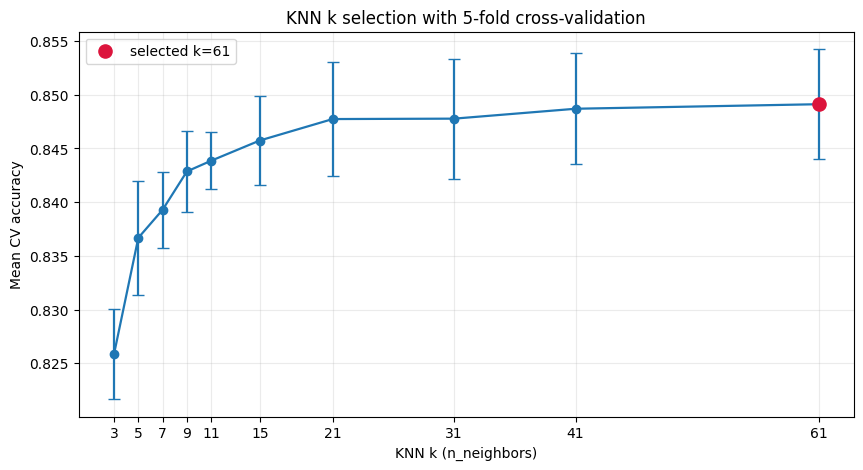

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, NUMERIC_FEATURES),
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(algorithm="brute", n_jobs=-1)),
    ]
)

K_VALUES = [3, 5, 7, 9, 11, 15, 21, 31, 41, 61]
N_FOLDS = 5
DISTANCE_METRIC_BY_P = {
    1: "manhattan",
    2: "euclidean",
}
KNN_TIE_BREAK_RULE = (
    "If rounded mean CV accuracies tie, choose the larger k for smoother neighborhoods, "
    "then Manhattan distance (p=1), then uniform weights."
)

cv_splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

param_grid = {
    "model__n_neighbors": K_VALUES,
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_splitter,
    refit=True,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_dev, y_dev)

fold_score_columns = [f"split{fold_idx}_test_score" for fold_idx in range(N_FOLDS)]
fold_accuracy_columns = [f"fold_{fold_idx + 1}_accuracy" for fold_idx in range(N_FOLDS)]

cv_results_df = pd.DataFrame(grid_search.cv_results_)[
    [
        "param_model__n_neighbors",
        "param_model__weights",
        "param_model__p",
        *fold_score_columns,
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score",
    ]
].rename(
    columns={
        "param_model__n_neighbors": "knn_k",
        "param_model__weights": "weights",
        "param_model__p": "p",
        **dict(zip(fold_score_columns, fold_accuracy_columns)),
        "mean_test_score": "mean_cv_accuracy",
        "std_test_score": "std_cv_accuracy",
        "mean_train_score": "mean_train_accuracy",
        "rank_test_score": "grid_rank",
    }
)

cv_results_df["knn_k"] = cv_results_df["knn_k"].astype(int)
cv_results_df["p"] = cv_results_df["p"].astype(int)
cv_results_df["distance_metric"] = cv_results_df["p"].map(DISTANCE_METRIC_BY_P)
cv_results_df["mean_cv_accuracy_rounded"] = cv_results_df["mean_cv_accuracy"].round(5)
cv_results_df["p_priority"] = cv_results_df["p"].map({1: 0, 2: 1})
cv_results_df["weights_priority"] = cv_results_df["weights"].map({"uniform": 0, "distance": 1})

cv_results_ranked_df = cv_results_df.sort_values(
    by=["mean_cv_accuracy_rounded", "knn_k", "p_priority", "weights_priority"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

selected_row = cv_results_ranked_df.iloc[0]
selected_params = {
    "model__n_neighbors": int(selected_row["knn_k"]),
    "model__weights": str(selected_row["weights"]),
    "model__p": int(selected_row["p"]),
}
selected_fold_accuracies = [float(selected_row[column]) for column in fold_accuracy_columns]
selected_fold_accuracy_records = [
    {
        "fold": fold_idx + 1,
        "knn_k": selected_params["model__n_neighbors"],
        "weights": selected_params["model__weights"],
        "p": selected_params["model__p"],
        "distance_metric": DISTANCE_METRIC_BY_P[selected_params["model__p"]],
        "accuracy": selected_fold_accuracies[fold_idx],
    }
    for fold_idx in range(N_FOLDS)
]

selected_pipeline = clone(base_pipeline).set_params(**selected_params)
selected_pipeline.fit(X_dev, y_dev)

selection_summary_df = pd.DataFrame(
    [
        {
            "selection_source": "GridSearchCV raw best params",
            "params": json.dumps(grid_search.best_params_, sort_keys=True),
            "mean_cv_accuracy": round(float(grid_search.best_score_), 5),
        },
        {
            "selection_source": "Notebook tie-break selection",
            "params": json.dumps(selected_params, sort_keys=True),
            "mean_cv_accuracy": round(float(selected_row["mean_cv_accuracy"]), 5),
        },
    ]
)

k_cv_summary_df = (
    cv_results_ranked_df.drop_duplicates(subset="knn_k", keep="first")
    .sort_values("knn_k")
    .reset_index(drop=True)
)
k_cv_summary_df["selected"] = np.where(
    k_cv_summary_df["knn_k"] == selected_params["model__n_neighbors"],
    "selected",
    "",
)

k_cv_display_df = k_cv_summary_df[
    [
        "knn_k",
        "weights",
        "distance_metric",
        *fold_accuracy_columns,
        "mean_cv_accuracy",
        "std_cv_accuracy",
        "selected",
    ]
].copy()
k_cv_display_df[fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy"]] = k_cv_display_df[
    fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy"]
].round(5)

selected_fold_accuracy_df = pd.DataFrame(selected_fold_accuracy_records)
selected_fold_accuracy_df["accuracy"] = selected_fold_accuracy_df["accuracy"].round(5)

optimal_k_summary = (
    "### Final cross-validation result\n"
    f"- KNN k (`n_neighbors`): `{selected_params['model__n_neighbors']}`\n"
    f"- weights: `{selected_params['model__weights']}`\n"
    f"- distance: `{DISTANCE_METRIC_BY_P[selected_params['model__p']]}` (`p={selected_params['model__p']}`)\n"
    f"- mean CV accuracy: `{float(selected_row['mean_cv_accuracy']):.5f}`\n"
    f"- fold accuracies: `{', '.join(f'{accuracy:.5f}' for accuracy in selected_fold_accuracies)}`\n"
    f"- tie-break rule: {KNN_TIE_BREAK_RULE}"
)

display(
    Markdown(
        "### Accuracy by KNN k\n"
        "Each row shows one KNN `k` value (`n_neighbors`). "
        "The fold columns show the accuracy from the 5 folds for that same `k`, "
        "using the best `weights` and distance combination found for that `k`."
    )
)
display(k_cv_display_df)

display(Markdown("### Folds for the selected k"))
display(selected_fold_accuracy_df)
display(selection_summary_df)
display(Markdown(optimal_k_summary))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    k_cv_summary_df["knn_k"],
    k_cv_summary_df["mean_cv_accuracy"],
    yerr=k_cv_summary_df["std_cv_accuracy"],
    fmt="o-",
    capsize=4,
    linewidth=1.6,
)
ax.scatter(
    [selected_params["model__n_neighbors"]],
    [float(selected_row["mean_cv_accuracy"])],
    color="crimson",
    s=90,
    label=f"selected k={selected_params['model__n_neighbors']}",
    zorder=3,
)
ax.set_title("KNN k selection with 5-fold cross-validation")
ax.set_xlabel("KNN k (n_neighbors)")
ax.set_ylabel("Mean CV accuracy")
ax.set_xticks(K_VALUES)
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Holdout Evaluation

After choosing hyperparameters with cross-validation, the selected model is evaluated on the holdout split. The holdout split was not used to choose `k`, so it gives a more honest estimate of performance on unseen data.

## Metrics Reported

- **Accuracy (`accuracy`)**: overall proportion of correct predictions.
- **Error rate (`1 - accuracy`)**: overall proportion of incorrect predictions.
- **Balanced accuracy**: average recall across classes, useful when classes are imbalanced.
- **Precision for class `>50K`**: among samples predicted as `>50K`, how many were truly `>50K`.
- **Recall / sensitivity for class `>50K`**: among truly `>50K` samples, how many the model found.
- **Specificity for class `<=50K`**: among truly `<=50K` samples, how many the model kept as `<=50K`.
- **F1-score for class `>50K`**: harmonic mean of precision and recall.
- **ROC AUC**: how well the model ranks positive samples above negative samples using predicted probabilities.

Holdout results in this experiment:

- Accuracy: approximately `0.84819`
- Error rate: approximately `0.15181`
- Balanced accuracy: approximately `0.77354`
- Precision `>50K`: approximately `0.70803`
- Recall / sensitivity `>50K`: approximately `0.62946`
- Specificity `<=50K`: approximately `0.91761`
- F1-score `>50K`: approximately `0.66644`
- ROC AUC: approximately `0.90215`

## Confusion Matrix

The confusion matrix shows where the model is correct and where it makes mistakes:

- **True negatives**: `<=50K` predicted as `<=50K`.
- **False positives**: `<=50K` incorrectly predicted as `>50K`.
- **False negatives**: `>50K` incorrectly predicted as `<=50K`.
- **True positives**: `>50K` predicted as `>50K`.

In this holdout split, the matrix is:

|                | Predicted `<=50K` | Predicted `>50K` |
|---|---:|---:|
| Actual `<=50K` | `4533` | `407` |
| Actual `>50K` | `581` | `987` |

The main takeaway is that the model performs strongly on the majority class `<=50K`, but still misses a meaningful share of `>50K` cases, which is reflected by the positive-class recall of approximately `0.62946`.


In [6]:
holdout_pred = selected_pipeline.predict(X_holdout)
holdout_proba = selected_pipeline.predict_proba(X_holdout)[:, 1]
holdout_accuracy = float(accuracy_score(y_holdout, holdout_pred))

tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_pred, labels=[0, 1]).ravel()
sensitivity = float(tp / (tp + fn)) if (tp + fn) else 0.0
specificity = float(tn / (tn + fp)) if (tn + fp) else 0.0

holdout_metrics = {
    "accuracy": holdout_accuracy,
    "error_rate": 1 - holdout_accuracy,
    "balanced_accuracy": float(balanced_accuracy_score(y_holdout, holdout_pred)),
    "precision_positive": float(precision_score(y_holdout, holdout_pred, zero_division=0)),
    "recall_positive": float(recall_score(y_holdout, holdout_pred, zero_division=0)),
    "sensitivity": sensitivity,
    "specificity": specificity,
    "f1_positive": float(f1_score(y_holdout, holdout_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_holdout, holdout_proba)),
}

holdout_metrics_df = pd.DataFrame(
    [
        {"metric": metric_name, "value": round(metric_value, 5)}
        for metric_name, metric_value in holdout_metrics.items()
    ]
)

confusion_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=[f"actual_{NEGATIVE_LABEL}", f"actual_{POSITIVE_LABEL}"],
    columns=[f"pred_{NEGATIVE_LABEL}", f"pred_{POSITIVE_LABEL}"],
)

confusion_terms_df = pd.DataFrame(
    [
        {"term": "true_negatives", "count": int(tn), "meaning": "<=50K predicted as <=50K"},
        {"term": "false_positives", "count": int(fp), "meaning": "<=50K incorrectly predicted as >50K"},
        {"term": "false_negatives", "count": int(fn), "meaning": ">50K incorrectly predicted as <=50K"},
        {"term": "true_positives", "count": int(tp), "meaning": ">50K predicted as >50K"},
    ]
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_holdout,
        holdout_pred,
        target_names=[NEGATIVE_LABEL, POSITIVE_LABEL],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(holdout_metrics_df)
display(confusion_df)
display(confusion_terms_df)
display(classification_report_df)


,metric,value
0,accuracy,0.84819
1,error_rate,0.15181
2,balanced_accuracy,0.77354
3,precision_positive,0.70803
4,recall_positive,0.62946
5,sensitivity,0.62946
6,specificity,0.91761
7,f1_positive,0.66644
8,roc_auc,0.90215


,pred_<=50K,pred_>50K
actual_<=50K,4533,407
actual_>50K,581,987


,term,count,meaning
0,true_negatives,4533,<=50K predicted as <=50K
1,false_positives,407,<=50K incorrectly predicted as >50K
2,false_negatives,581,>50K incorrectly predicted as <=50K
3,true_positives,987,>50K predicted as >50K


,precision,recall,f1-score,support
<=50K,0.886390,0.917611,0.901731,4940.000000
>50K,0.708034,0.629464,0.666442,1568.000000
accuracy,0.848187,0.848187,0.848187,0.848187
macro avg,0.797212,0.773538,0.784086,6508.000000
weighted avg,0.843418,0.848187,0.845041,6508.000000


## kNN Feature-Space Geometry

kNN does not learn one single linear boundary like logistic regression or a linear SVM. It classifies each new sample by looking at nearby samples in the transformed feature space.

The visualization below uses 2D PCA only to make the feature space easier to inspect. The actual model uses all preprocessed features, not only these two axes.

This section is meant to show that:

- each prediction depends on the local neighborhood around the sample;
- `k=61` controls how many neighbors participate in the vote;
- with `weights=uniform`, each of the 61 neighbors has the same vote weight;
- with Manhattan distance (`p=1`), closeness is computed as the sum of absolute coordinate differences.


### How the selected kNN model works
kNN does **not** learn a single hyperplane. It predicts each query point from the **vote of its nearest neighbors** in the transformed feature space. The plots below show that neighborhood logic directly.

/tmp/ipykernel_133157/3664777115.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


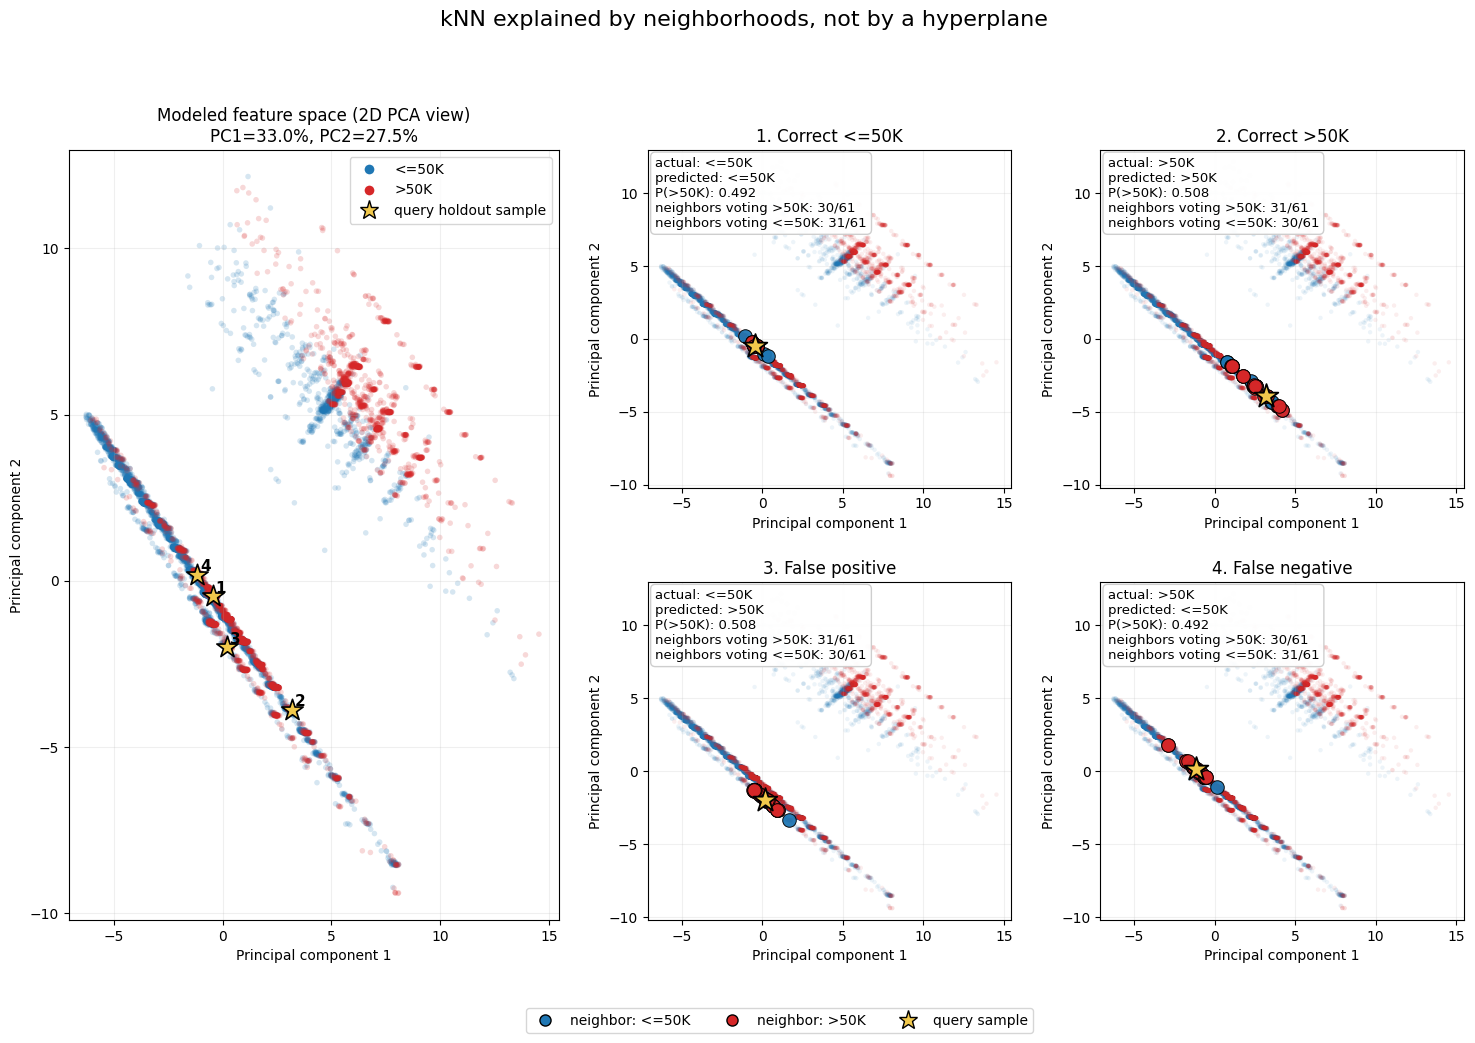

In [7]:
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

display(
    Markdown(
        "### How the selected kNN model works\n"
        "kNN does **not** learn a single hyperplane. "
        "It predicts each query point from the **vote of its nearest neighbors** "
        "in the transformed feature space. "
        "The plots below show that neighborhood logic directly."
    )
)

# Use the exact fitted pipeline chosen during model selection.
preprocessor = selected_pipeline.named_steps["preprocessor"]
knn_model = selected_pipeline.named_steps["model"]

# Transform features into the same space used by kNN.
X_dev_trans = preprocessor.transform(X_dev)
X_holdout_trans = preprocessor.transform(X_holdout)

y_dev_array = y_dev.to_numpy()
y_holdout_array = y_holdout.to_numpy()
holdout_pred = selected_pipeline.predict(X_holdout)
holdout_proba = selected_pipeline.predict_proba(X_holdout)[:, 1]

# 2D PCA is used only for visualization of the modeled feature space.
pca_2d = PCA(n_components=2)
X_dev_vis = pca_2d.fit_transform(X_dev_trans)
X_holdout_vis = pca_2d.transform(X_holdout_trans)

# Pick representative holdout cases:
# one correct negative, one correct positive, one false positive, one false negative.
case_definitions = [
    ("Correct <=50K", (y_holdout_array == 0) & (holdout_pred == 0)),
    ("Correct >50K", (y_holdout_array == 1) & (holdout_pred == 1)),
    ("False positive", (y_holdout_array == 0) & (holdout_pred == 1)),
    ("False negative", (y_holdout_array == 1) & (holdout_pred == 0)),
]

selected_cases = []
used_indices = set()

def pick_most_boundary_case(mask):
    candidate_idx = np.where(mask)[0]
    candidate_idx = np.array([idx for idx in candidate_idx if idx not in used_indices])
    if len(candidate_idx) == 0:
        return None
    chosen = candidate_idx[np.argmin(np.abs(holdout_proba[candidate_idx] - 0.5))]
    used_indices.add(int(chosen))
    return int(chosen)

for label, mask in case_definitions:
    idx = pick_most_boundary_case(mask)
    if idx is not None:
        selected_cases.append((label, idx))

# If one error type does not exist, fill the remaining slots with the most uncertain unused holdout samples.
if len(selected_cases) < 4:
    remaining = np.array([idx for idx in range(len(X_holdout_vis)) if idx not in used_indices])
    remaining = remaining[np.argsort(np.abs(holdout_proba[remaining] - 0.5))]
    for idx in remaining[: 4 - len(selected_cases)]:
        used_indices.add(int(idx))
        selected_cases.append(("Most uncertain holdout sample", int(idx)))

# Shared plot limits
all_vis = np.vstack([X_dev_vis, X_holdout_vis])
x_pad = 0.8
y_pad = 0.8
x_min, x_max = all_vis[:, 0].min() - x_pad, all_vis[:, 0].max() + x_pad
y_min, y_max = all_vis[:, 1].min() - y_pad, all_vis[:, 1].max() + y_pad

class_colors = {
    0: "#1f77b4",  # <=50K
    1: "#d62728",  # >50K
}
class_names = {
    0: NEGATIVE_LABEL,
    1: POSITIVE_LABEL,
}

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[1.35, 1, 1], hspace=0.28, wspace=0.22)

# Overview panel
ax_overview = fig.add_subplot(gs[:, 0])

for cls in [0, 1]:
    cls_mask = y_dev_array == cls
    ax_overview.scatter(
        X_dev_vis[cls_mask, 0],
        X_dev_vis[cls_mask, 1],
        s=16,
        alpha=0.18,
        c=class_colors[cls],
        edgecolor="none",
    )

for case_number, (_, idx) in enumerate(selected_cases, start=1):
    ax_overview.scatter(
        X_holdout_vis[idx, 0],
        X_holdout_vis[idx, 1],
        s=260,
        marker="*",
        c="#f2c94c",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )
    ax_overview.text(
        X_holdout_vis[idx, 0] + 0.12,
        X_holdout_vis[idx, 1] + 0.12,
        str(case_number),
        fontsize=11,
        weight="bold",
        color="black",
    )

ax_overview.set_xlim(x_min, x_max)
ax_overview.set_ylim(y_min, y_max)
ax_overview.set_title(
    "Modeled feature space (2D PCA view)\n"
    f"PC1={pca_2d.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.1%}"
)
ax_overview.set_xlabel("Principal component 1")
ax_overview.set_ylabel("Principal component 2")
ax_overview.grid(alpha=0.2)

overview_legend = [
    Line2D([0], [0], marker="o", color="w", label=NEGATIVE_LABEL, markerfacecolor=class_colors[0], markersize=8),
    Line2D([0], [0], marker="o", color="w", label=POSITIVE_LABEL, markerfacecolor=class_colors[1], markersize=8),
    Line2D([0], [0], marker="*", color="w", label="query holdout sample", markerfacecolor="#f2c94c", markeredgecolor="black", markersize=14),
]
ax_overview.legend(handles=overview_legend, loc="upper right", frameon=True)

# Neighborhood panels
case_axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

for plot_idx, ((case_label, holdout_idx), ax) in enumerate(zip(selected_cases, case_axes), start=1):
    query_xy = X_holdout_vis[holdout_idx]
    query_trans = X_holdout_trans[holdout_idx].reshape(1, -1)

    neighbor_distances, neighbor_indices = knn_model.kneighbors(query_trans, return_distance=True)
    neighbor_distances = neighbor_distances[0]
    neighbor_indices = neighbor_indices[0]

    neighbor_xy = X_dev_vis[neighbor_indices]
    neighbor_y = y_dev_array[neighbor_indices]

    positive_votes = int(neighbor_y.sum())
    negative_votes = int(len(neighbor_y) - positive_votes)
    predicted_class = int(holdout_pred[holdout_idx])
    actual_class = int(y_holdout_array[holdout_idx])

    # Background cloud
    for cls in [0, 1]:
        cls_mask = y_dev_array == cls
        ax.scatter(
            X_dev_vis[cls_mask, 0],
            X_dev_vis[cls_mask, 1],
            s=10,
            alpha=0.08,
            c=class_colors[cls],
            edgecolor="none",
        )

    # Draw neighbor links
    for nb_xy, nb_dist in zip(neighbor_xy, neighbor_distances):
        ax.plot(
            [query_xy[0], nb_xy[0]],
            [query_xy[1], nb_xy[1]],
            color="#7f8c8d",
            alpha=0.18,
            linewidth=0.8,
            zorder=1,
        )

    # Highlight selected neighbors
    for cls in [0, 1]:
        cls_mask = neighbor_y == cls
        ax.scatter(
            neighbor_xy[cls_mask, 0],
            neighbor_xy[cls_mask, 1],
            s=95,
            c=class_colors[cls],
            edgecolor="black",
            linewidth=0.7,
            alpha=0.95,
            zorder=3,
        )

    # Query point
    ax.scatter(
        query_xy[0],
        query_xy[1],
        s=320,
        marker="*",
        c="#f2c94c",
        edgecolor="black",
        linewidth=1.3,
        zorder=4,
    )

    summary_text = (
        f"actual: {class_names[actual_class]}\n"
        f"predicted: {class_names[predicted_class]}\n"
        f"P(>50K): {holdout_proba[holdout_idx]:.3f}\n"
        f"neighbors voting >50K: {positive_votes}/{knn_model.n_neighbors}\n"
        f"neighbors voting <=50K: {negative_votes}/{knn_model.n_neighbors}"
    )

    ax.text(
        0.02,
        0.98,
        summary_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#cccccc", alpha=0.95),
    )

    ax.set_title(f"{plot_idx}. {case_label}")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Principal component 1")
    ax.set_ylabel("Principal component 2")
    ax.grid(alpha=0.18)

detail_legend = [
    Line2D([0], [0], marker="o", color="w", label="neighbor: <=50K", markerfacecolor=class_colors[0], markeredgecolor="black", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="neighbor: >50K", markerfacecolor=class_colors[1], markeredgecolor="black", markersize=8),
    Line2D([0], [0], marker="*", color="w", label="query sample", markerfacecolor="#f2c94c", markeredgecolor="black", markersize=14),
]

fig.legend(
    handles=detail_legend,
    loc="lower center",
    bbox_to_anchor=(0.52, -0.01),
    ncol=3,
    frameon=True,
)

fig.suptitle(
    "kNN explained by neighborhoods, not by a hyperplane",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()


## Interpretable Plots With Real Variables

PCA helps visualize the transformed feature space, but its axes do not map directly to a single original feature. The next visualizations use real dataset variables instead.

These plots do not replace model metrics, but they help explain broad patterns in the data, such as differences by sex, weekly hours, and income group.


,sex,count,mean,median,std
0,Female,10762,36.42,40.0,11.81
1,Male,21774,42.43,40.0,12.12


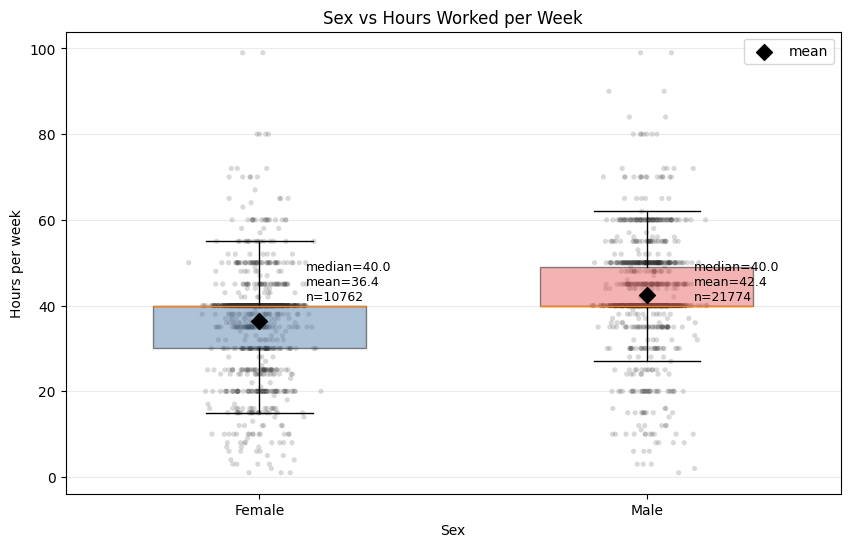

In [8]:
# sex vs hours.per.week

plot_df = train_prepared[["sex", "hours.per.week"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist())

summary_df = (
    plot_df.groupby("sex")["hours.per.week"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

display(summary_df)

fig, ax = plt.subplots(figsize=(10, 6))

hours_by_sex = [
    plot_df.loc[plot_df["sex"] == sex_value, "hours.per.week"].to_numpy()
    for sex_value in sex_order
]

box = ax.boxplot(
    hours_by_sex,
    tick_labels=sex_order,
    patch_artist=True,
    widths=0.55,
    showfliers=False,
)

box_colors = ["#4C78A8", "#E45756"]
for patch, color in zip(box["boxes"], box_colors[: len(box["boxes"])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)

rng = np.random.default_rng(42)
for idx, sex_value in enumerate(sex_order, start=1):
    y_values = plot_df.loc[plot_df["sex"] == sex_value, "hours.per.week"].to_numpy()
    sample_size = min(1200, len(y_values))
    sampled = rng.choice(y_values, size=sample_size, replace=False)
    x_jitter = rng.normal(loc=idx, scale=0.05, size=sample_size)

    ax.scatter(
        x_jitter,
        sampled,
        s=14,
        alpha=0.18,
        color="#2f2f2f",
        edgecolors="none",
    )

    median_value = np.median(y_values)
    mean_value = np.mean(y_values)

    ax.scatter(
        idx,
        mean_value,
        color="black",
        s=65,
        marker="D",
        zorder=4,
        label="mean" if idx == 1 else None,
    )

    ax.text(
        idx + 0.12,
        median_value + 0.6,
        f"median={median_value:.1f}\nmean={mean_value:.1f}\nn={len(y_values)}",
        fontsize=9,
        va="bottom",
    )

ax.set_title("Sex vs Hours Worked per Week")
ax.set_xlabel("Sex")
ax.set_ylabel("Hours per week")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right", frameon=True)
plt.show()


income,sex,<=50K,>50K
0,Female,9583,1179
1,Male,15114,6660


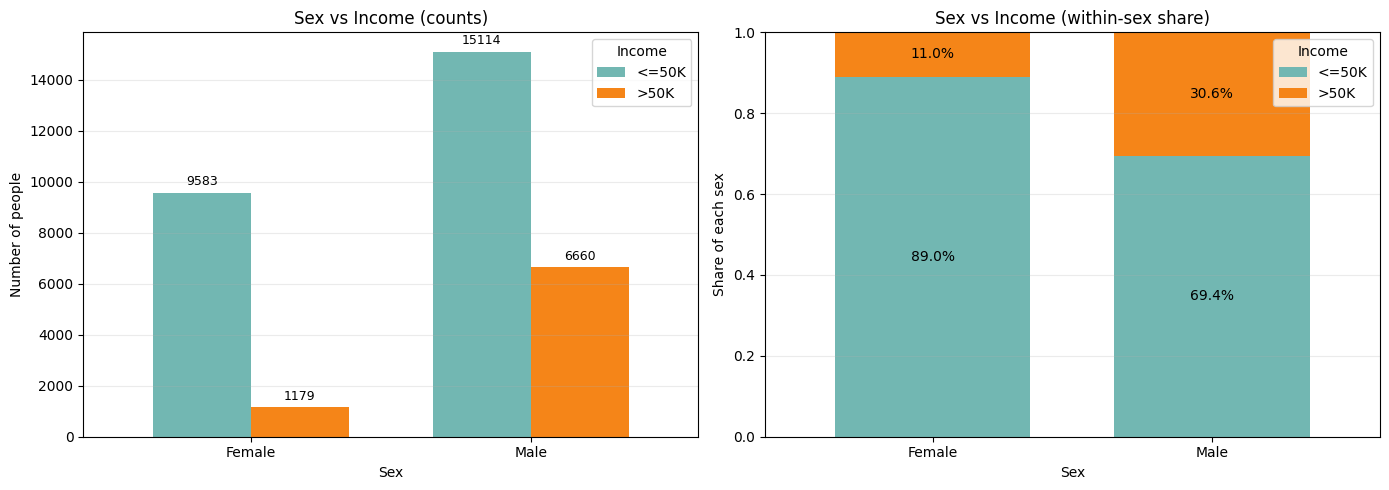

In [9]:
# sex vs income

plot_df = train_prepared[["sex", "income"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist()) 
income_order = ["<=50K", ">50K"]

count_df = (
    pd.crosstab(plot_df["sex"], plot_df["income"])
    .reindex(index=sex_order, columns=income_order)
    .fillna(0)
    .astype(int)
)

share_df = count_df.div(count_df.sum(axis=1), axis=0)

display(count_df.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

count_df.plot(
    kind="bar",
    ax=axes[0],
    color=["#72B7B2", "#F58518"],
    width=0.7,
)

axes[0].set_title("Sex vs Income (counts)")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Number of people")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(title="Income", frameon=True)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=9)

share_df.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#72B7B2", "#F58518"],
    width=0.7,
)

axes[1].set_title("Sex vs Income (within-sex share)")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Share of each sex")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(title="Income", frameon=True, loc="upper right")

for sex_idx, sex_value in enumerate(sex_order):
    running_height = 0
    for income_value in income_order:
        value = share_df.loc[sex_value, income_value]
        if value > 0:
            axes[1].text(
                sex_idx,
                running_height + value / 2,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=10,
                color="black",
            )
            running_height += value

plt.tight_layout()
plt.show()


## Final Training and Submission Generation

After holdout evaluation, the selected pipeline is fit again using **the full labeled training set**.

This is done because, once the hyperparameters have been selected and evaluated, we want to use all available labeled examples to generate predictions for the competition test set.

Important notes:

- The final test set does not include `income`, so local accuracy cannot be computed on it.
- The reliable metrics in this notebook come from the holdout split.
- `knn_submission.csv` contains only the final predictions for submission.

Saved artifacts:

- `submissions/knn_best_params.json`: selected hyperparameters and fold accuracies.
- `submissions/knn_holdout_metrics.json`: holdout metrics and confusion matrix.
- `submissions/knn_submission.csv`: final predictions for the test set.


In [10]:
final_pipeline = clone(base_pipeline).set_params(**selected_params)
final_pipeline.fit(X_train_full, y_binary)

test_pred_binary = final_pipeline.predict(X_test_final)
test_pred_labels = np.where(test_pred_binary == 1, POSITIVE_LABEL, NEGATIVE_LABEL)

submission_df = pd.DataFrame(
    {
        ID_COL: test_prepared[ID_COL].values,
        TARGET_COL: test_pred_labels,
    }
)

assert submission_df.columns.tolist() == [ID_COL, TARGET_COL], "Submission columns must be Id and income."
assert len(submission_df) == len(test_prepared), "Submission row count must match test_prepared.csv."
assert set(submission_df[TARGET_COL].unique()).issubset({NEGATIVE_LABEL, POSITIVE_LABEL}), "Submission labels must be <=50K or >50K."

submission_path = SUBMISSIONS_DIR / "knn_submission.csv"
metrics_path = SUBMISSIONS_DIR / "knn_holdout_metrics.json"
best_params_path = SUBMISSIONS_DIR / "knn_best_params.json"

holdout_metrics_payload = {
    "selected_params": selected_params,
    "best_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "holdout_metrics": holdout_metrics,
    "holdout_confusion_matrix": confusion_df.to_dict(),
    "holdout_confusion_terms": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    },
    "evaluation_protocol": {
        "development_split": "80% of labeled train_prepared.csv, stratified, used for CV/model selection",
        "holdout_split": "20% of labeled train_prepared.csv, stratified, used only for final local evaluation",
        "competition_test": "test_prepared.csv, no local labels, used only for final submission predictions",
        "cv": f"{N_FOLDS}-fold StratifiedKFold with shuffle=True and random_state=42",
        "selection_metric": "accuracy",
    },
}

best_params_payload = {
    "grid_search_best_params": grid_search.best_params_,
    "tie_break_selected_params": selected_params,
    "tie_break_changed_selection": bool(grid_search.best_params_ != selected_params),
    "tie_break_rule": KNN_TIE_BREAK_RULE,
    "selected_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "selected_mean_cv_accuracy_rounded": float(selected_row["mean_cv_accuracy_rounded"]),
    "selected_std_cv_accuracy": float(selected_row["std_cv_accuracy"]),
    "selected_fold_accuracies": selected_fold_accuracies,
    "selected_fold_accuracy_by_fold": selected_fold_accuracy_records,
    "tested_k_values": K_VALUES,
    "tested_weights": ["uniform", "distance"],
    "tested_p_values": [1, 2],
}

submission_df.to_csv(submission_path, index=False)
metrics_path.write_text(json.dumps(holdout_metrics_payload, indent=2))
best_params_path.write_text(json.dumps(best_params_payload, indent=2))

saved_artifacts_df = pd.DataFrame(
    [
        {"artifact": "submission", "path": str(submission_path.relative_to(PROJECT_ROOT))},
        {"artifact": "holdout_metrics", "path": str(metrics_path.relative_to(PROJECT_ROOT))},
        {"artifact": "best_params", "path": str(best_params_path.relative_to(PROJECT_ROOT))},
    ]
)

display(saved_artifacts_df)
display(submission_df.head())
display(Markdown(f"Submission saved to `{submission_path.relative_to(PROJECT_ROOT)}`."))


,artifact,path
0,submission,submissions/knn_submission.csv
1,holdout_metrics,submissions/knn_holdout_metrics.json
2,best_params,submissions/knn_best_params.json


,Id,income
0,0,<=50K
1,1,>50K
2,2,<=50K
3,3,<=50K
4,4,>50K


Submission saved to `submissions/knn_submission.csv`.